In [1]:
import pandas as pd
import matplotlib.pyplot as plt

DATASET 1: TITANIC

TITANIC DATASET

1. LOAD AND EXPLORE DATASET
   PassengerId  Survived  Pclass                          Name     Sex  Age  \
0            1         0       3       Braund, Mr. Owen Harris    male   22   
1            2         1       1    Cumings, Mrs. John Bradley  female   38   
2            3         1       3        Heikkinen, Miss. Laina  female   26   
3            4         1       1  Futrelle, Mrs. Jacques Heath  female   35   
4            5         0       3      Allen, Mr. William Henry    male   35   

   SibSp  Parch            Ticket     Fare Cabin Embarked  
0      1      0         A/5 21171   7.2500   NaN        S  
1      1      0          PC 17599  71.2833   C85        C  
2      0      0  STON/O2. 3101282   7.9250   NaN        S  
3      1      0            113803  53.1000  C123        S  
4      0      0            373450   8.0500   NaN        S  

Shape: (20, 12)

Columns:
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'T

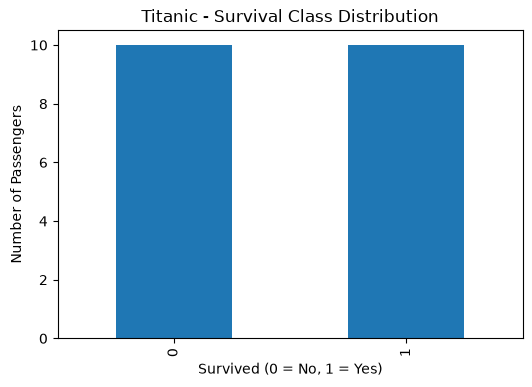


6. GENDER REPRESENTATION
Sex
female    11
male       9
Name: count, dtype: int64


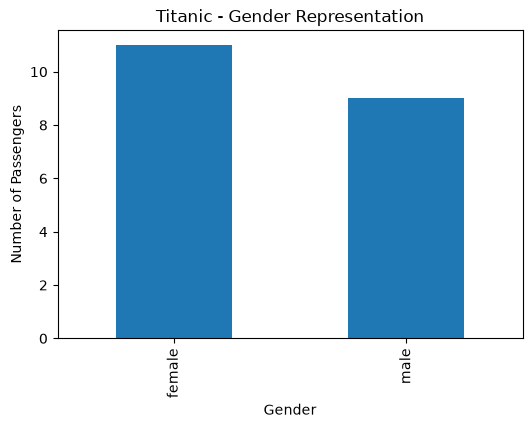


7. SURVIVAL BY GENDER
Survived  0  1
Sex           
female    2  9
male      8  1


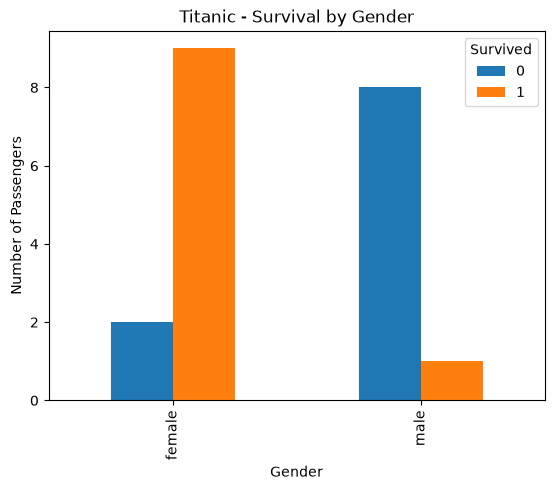


8. PASSENGER-CLASS REPRESENTATION
Pclass
3    13
1     4
2     3
Name: count, dtype: int64


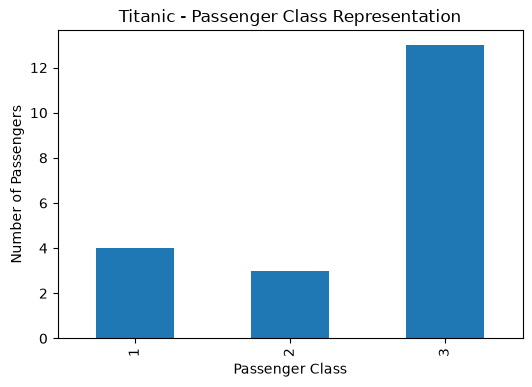


9. SURVIVAL BY PASSENGER CLASS
Survived  0  1
Pclass        
1         1  3
2         0  3
3         9  4


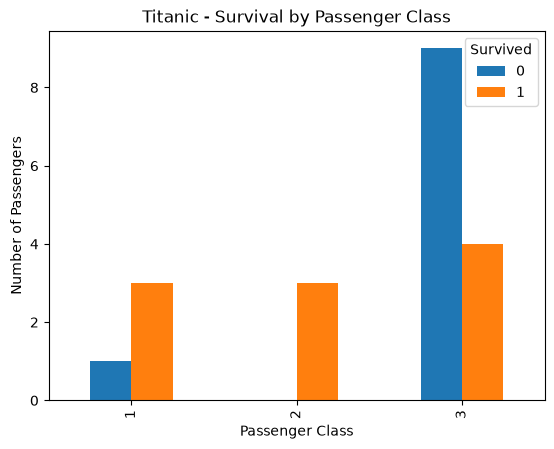


10. AGE GROUPS
AgeGroup
Young Adult    10
Adult           5
Child           3
Teen            2
Senior          0
Name: count, dtype: int64


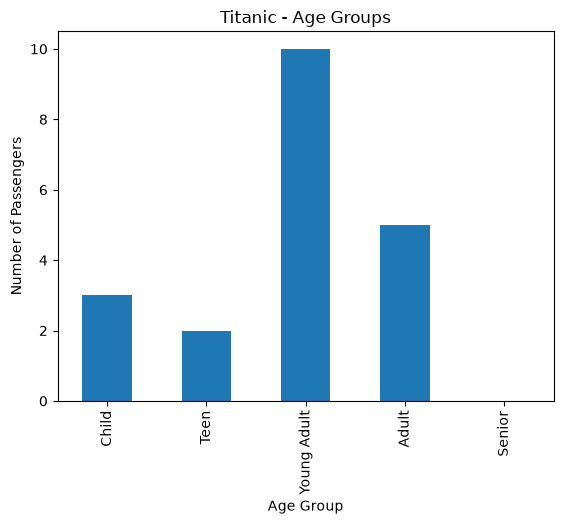


11. SURVIVAL BY AGE GROUP
Survived     0  1
AgeGroup         
Child        2  1
Teen         1  1
Young Adult  5  5
Adult        2  3


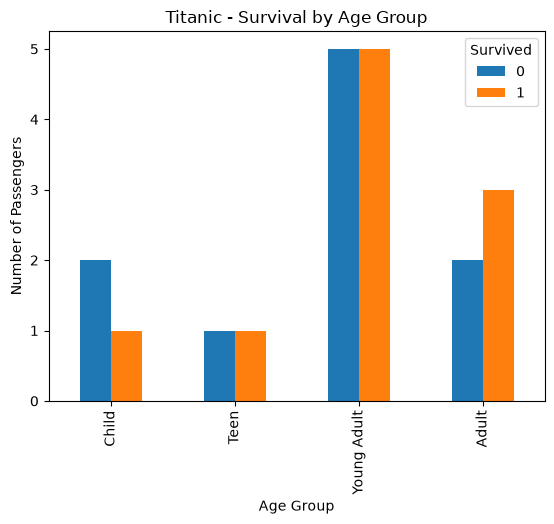


12. POSSIBLE BIAS

Survival Percentage by Gender:
Survived          0          1
Sex                           
female    18.181818  81.818182
male      88.888889  11.111111

Survival Percentage by Passenger Class:
Survived          0           1
Pclass                         
1         25.000000   75.000000
2          0.000000  100.000000
3         69.230769   30.769231

Survival Percentage by Age Group:
Survived             0          1
AgeGroup                         
Child        66.666667  33.333333
Teen         50.000000  50.000000
Young Adult  50.000000  50.000000
Adult        40.000000  60.000000

13. IMPACT ON MACHINE LEARNING

- The model may learn demographic patterns.
- Predictions may be less reliable for underrepresented groups.
- Historical bias may be reproduced by the model.


14. SUGGESTED SOLUTIONS

- Handle missing values.
- Use stratified sampling.
- Check model performance for different groups.
- Use suitable balancing techniques.
- Evaluate fairness along with

In [11]:
df = pd.read_csv("Titanic_train.csv")
print("=" * 60)
print("TITANIC DATASET")
print("=" * 60)

# 1. Load and Explore Dataset
print("\n1. LOAD AND EXPLORE DATASET")
print(df.head())
print("\nShape:", df.shape)
print("\nColumns:")
print(df.columns)

# 2. Check Data Quality
print("\n2. CHECK DATA QUALITY")
print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

# Fill missing Age
df["Age"] = df["Age"].fillna(df["Age"].median())

# 3. Identify Target Variable
print("\n3. TARGET VARIABLE")
print("Target Variable: Survived")

# 4. Analyze Class Distribution
print("\n4. CLASS DISTRIBUTION")
print(df["Survived"].value_counts())

print("\nClass Percentage:")
print(df["Survived"].value_counts(normalize=True) * 100)

# 5. Visualize Class Imbalance
plt.figure(figsize=(6,4))
df["Survived"].value_counts().plot(kind="bar")
plt.title("Titanic - Survival Class Distribution")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")
plt.show()

# 6. Gender Representation
print("\n6. GENDER REPRESENTATION")
print(df["Sex"].value_counts())

plt.figure(figsize=(6,4))
df["Sex"].value_counts().plot(kind="bar")
plt.title("Titanic - Gender Representation")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")
plt.show()

# 7. Survival by Gender
print("\n7. SURVIVAL BY GENDER")
print(pd.crosstab(df["Sex"], df["Survived"]))

pd.crosstab(df["Sex"], df["Survived"]).plot(kind="bar")
plt.title("Titanic - Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")
plt.show()

# 8. Passenger-Class Representation
print("\n8. PASSENGER-CLASS REPRESENTATION")
print(df["Pclass"].value_counts())

plt.figure(figsize=(6,4))
df["Pclass"].value_counts().sort_index().plot(kind="bar")
plt.title("Titanic - Passenger Class Representation")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.show()

# 9. Survival by Passenger Class
print("\n9. SURVIVAL BY PASSENGER CLASS")
print(pd.crosstab(df["Pclass"], df["Survived"]))

pd.crosstab(df["Pclass"], df["Survived"]).plot(kind="bar")
plt.title("Titanic - Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.show()

# 10. Analyze Age Groups
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0, 12, 18, 35, 60, 100],
    labels=["Child", "Teen", "Young Adult", "Adult", "Senior"]
)

print("\n10. AGE GROUPS")
print(df["AgeGroup"].value_counts())

df["AgeGroup"].value_counts().sort_index().plot(kind="bar")
plt.title("Titanic - Age Groups")
plt.xlabel("Age Group")
plt.ylabel("Number of Passengers")
plt.show()

# 11. Survival by Age Group
print("\n11. SURVIVAL BY AGE GROUP")
print(pd.crosstab(df["AgeGroup"], df["Survived"]))

pd.crosstab(df["AgeGroup"], df["Survived"]).plot(kind="bar")
plt.title("Titanic - Survival by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Passengers")
plt.show()

#12. IDENTIFY POSSIBLE BIAS
print("\n12. POSSIBLE BIAS")

# Gender bias analysis
gender_bias = pd.crosstab(
    df["Sex"],
    df["Survived"],
    normalize="index"
) * 100

print("\nSurvival Percentage by Gender:")
print(gender_bias)

# Passenger class bias analysis
class_bias = pd.crosstab(
    df["Pclass"],
    df["Survived"],
    normalize="index"
) * 100

print("\nSurvival Percentage by Passenger Class:")
print(class_bias)

# Age group bias analysis
age_bias = pd.crosstab(
    df["AgeGroup"],
    df["Survived"],
    normalize="index"
) * 100

print("\nSurvival Percentage by Age Group:")
print(age_bias)

# 13. Impact on ML
print("\n13. IMPACT ON MACHINE LEARNING")
print("""
- The model may learn demographic patterns.
- Predictions may be less reliable for underrepresented groups.
- Historical bias may be reproduced by the model.
""")

# 14. Suggested Solutions
print("\n14. SUGGESTED SOLUTIONS")
print("""
- Handle missing values.
- Use stratified sampling.
- Check model performance for different groups.
- Use suitable balancing techniques.
- Evaluate fairness along with accuracy.
""")

# 15. Final Conclusion
print("\n15. FINAL CONCLUSION")
print("""
The Titanic dataset contains differences in gender, passenger class
and age representation. These differences can introduce bias into
machine-learning models. Therefore, fairness should be evaluated
before using the model for prediction.
""")
print("KHUSHI T032")

 DATASET 2: GERMAN CREDIT RISK



 GERMAN CREDIT RISK

1. LOAD AND EXPLORE DATASET
   Age     Sex  Job Housing Saving accounts Checking account  Credit amount  \
0   67    male    2     own          little           little           1169   
1   22  female    2     own          little         moderate           5951   
2   49    male    1     own          little           little           2096   
3   45    male    2    free          little           little           7882   
4   53    male    2    free          little           little           4870   

   Duration              Purpose  Risk  
0         6             radio/TV  good  
1        48             radio/TV   bad  
2        12            education  good  
3        42  furniture/equipment  good  
4        24                  car   bad  

Shape: (20, 10)

Columns:
Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='str')

2. CHECK DATA QUALITY

Missing Values:
Age     

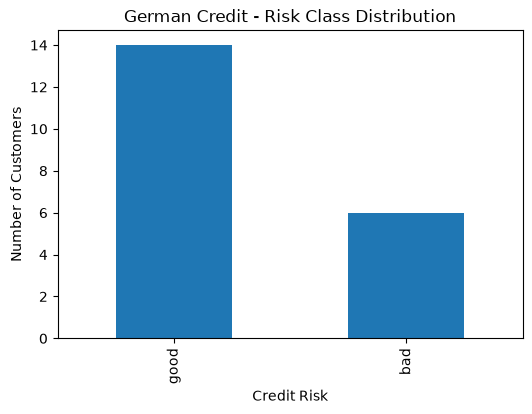


6. GENDER REPRESENTATION
Sex
male      14
female     6
Name: count, dtype: int64


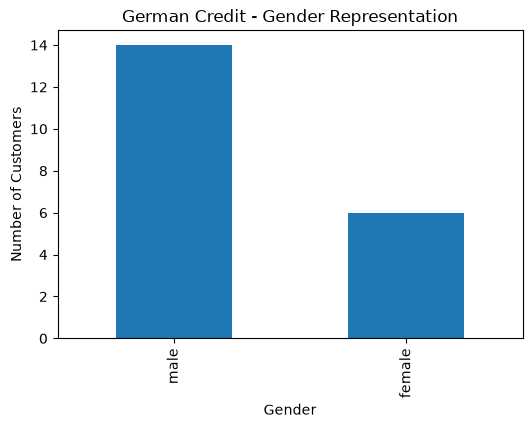


7. CREDIT RISK BY GENDER
Risk    bad  good
Sex              
female    4     2
male      2    12


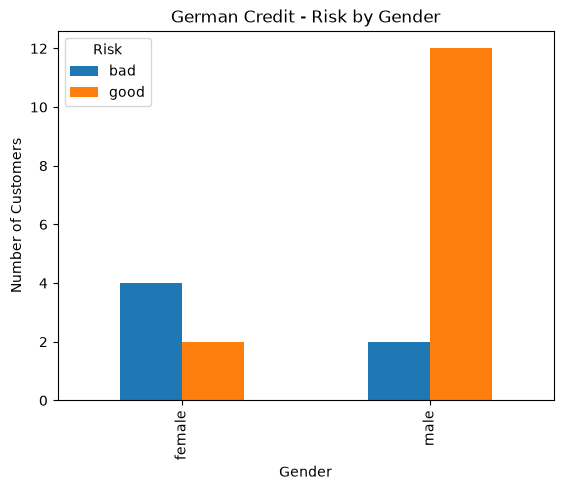


8. AGE GROUPS
AgeGroup
Adult          7
Young          4
Middle Age     4
Senior         4
Very Senior    1
Name: count, dtype: int64


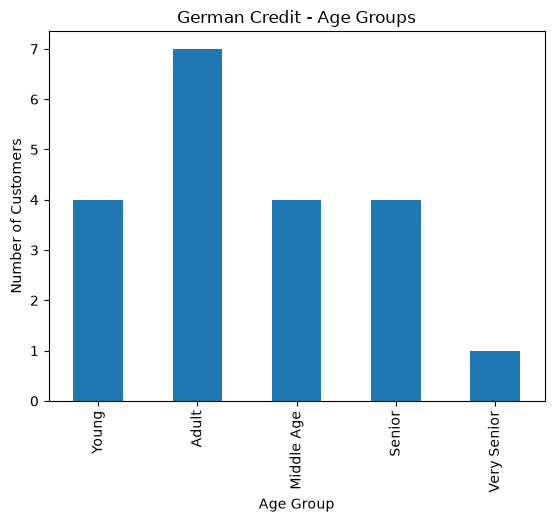


9. CREDIT RISK BY AGE GROUP
Risk         bad  good
AgeGroup              
Young          4     0
Adult          1     6
Middle Age     0     4
Senior         1     3
Very Senior    0     1


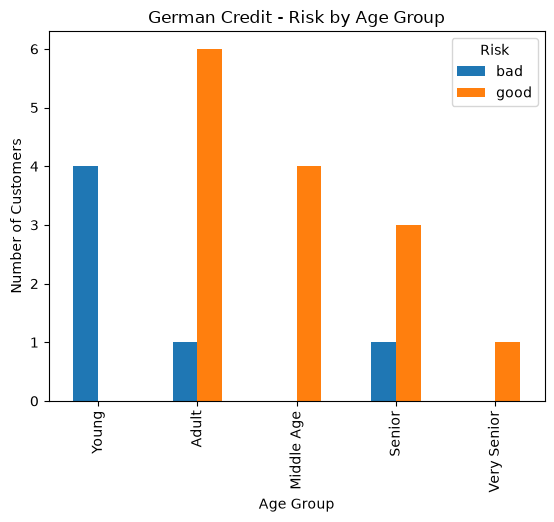


10. HOUSING CATEGORY REPRESENTATION
Housing
own     12
rent     5
free     3
Name: count, dtype: int64


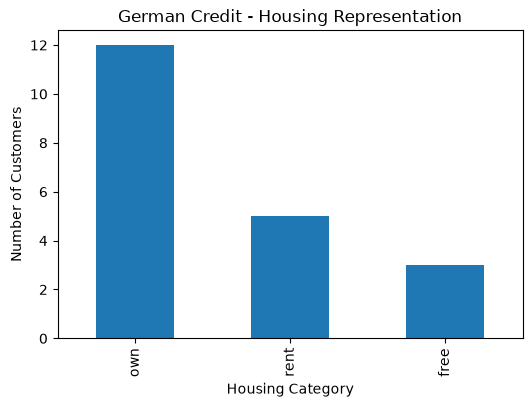


11. CREDIT RISK BY HOUSING
Risk     bad  good
Housing           
free       1     2
own        2    10
rent       3     2


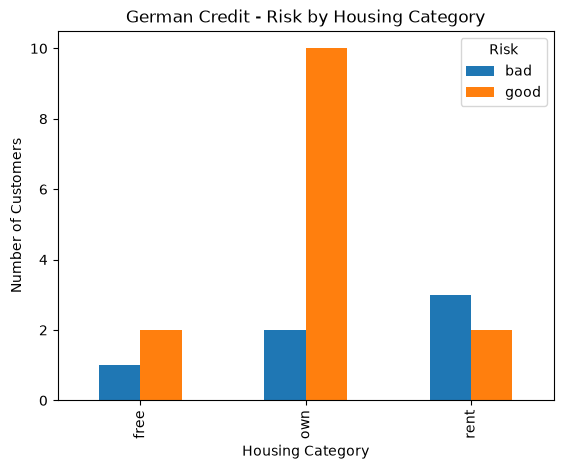


12. POSSIBLE BIAS

- Gender groups may have unequal representation.
- Age groups may have unequal representation.
- Housing categories may have unequal representation.
- Credit-risk classes may be imbalanced.


13. IMPACT ON MACHINE LEARNING

- The model may favor majority groups.
- Minority groups may have lower prediction accuracy.
- Historical credit patterns may introduce unfairness.


14. SUGGESTED SOLUTIONS

- Handle missing values.
- Use stratified sampling.
- Balance classes where appropriate.
- Compare model performance across groups.
- Remove irrelevant features.
- Perform fairness evaluation.


15. FINAL CONCLUSION

The German Credit dataset may contain class and demographic imbalance.
Gender, age and housing categories can influence credit-risk patterns.
Therefore, proper preprocessing and fairness evaluation are important
before using the dataset for machine-learning applications.

KHUSHI T032


In [15]:
df = pd.read_csv("German_Credit_Risk.csv")
print("\n\n" + "=" * 60)
print(" GERMAN CREDIT RISK")
print("=" * 60)

# 1. Load and Explore Dataset
print("\n1. LOAD AND EXPLORE DATASET")
print(df.head())
print("\nShape:", df.shape)
print("\nColumns:")
print(df.columns)

# 2. Check Data Quality
print("\n2. CHECK DATA QUALITY")

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

# 3. Identify Target Variable
print("\n3. TARGET VARIABLE")
print("Target Variable: Risk")

# 4. Analyze Class Distribution
print("\n4. CLASS DISTRIBUTION")
print(df["Risk"].value_counts())

print("\nClass Percentage:")
print(df["Risk"].value_counts(normalize=True) * 100)

# 5. Visualize Class Imbalance
plt.figure(figsize=(6,4))
df["Risk"].value_counts().plot(kind="bar")
plt.title("German Credit - Risk Class Distribution")
plt.xlabel("Credit Risk")
plt.ylabel("Number of Customers")
plt.show()

# 6. Gender Representation
print("\n6. GENDER REPRESENTATION")
print(df["Sex"].value_counts())

plt.figure(figsize=(6,4))
df["Sex"].value_counts().plot(kind="bar")
plt.title("German Credit - Gender Representation")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.show()

# 7. Credit Risk by Gender
print("\n7. CREDIT RISK BY GENDER")
print(pd.crosstab(df["Sex"], df["Risk"]))

pd.crosstab(df["Sex"], df["Risk"]).plot(kind="bar")
plt.title("German Credit - Risk by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.show()

# 8. Age Groups
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0, 25, 35, 50, 65, 100],
    labels=["Young", "Adult", "Middle Age", "Senior", "Very Senior"]
)

print("\n8. AGE GROUPS")
print(df["AgeGroup"].value_counts())

df["AgeGroup"].value_counts().sort_index().plot(kind="bar")
plt.title("German Credit - Age Groups")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")
plt.show()

# 9. Credit Risk by Age Group
print("\n9. CREDIT RISK BY AGE GROUP")
print(pd.crosstab(df["AgeGroup"], df["Risk"]))

pd.crosstab(df["AgeGroup"], df["Risk"]).plot(kind="bar")
plt.title("German Credit - Risk by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")
plt.show()

# 10. Housing Category Representation
print("\n10. HOUSING CATEGORY REPRESENTATION")
print(df["Housing"].value_counts())

plt.figure(figsize=(6,4))
df["Housing"].value_counts().plot(kind="bar")
plt.title("German Credit - Housing Representation")
plt.xlabel("Housing Category")
plt.ylabel("Number of Customers")
plt.show()

# 11. Credit Risk by Housing Category
print("\n11. CREDIT RISK BY HOUSING")
print(pd.crosstab(df["Housing"], df["Risk"]))

pd.crosstab(df["Housing"], df["Risk"]).plot(kind="bar")
plt.title("German Credit - Risk by Housing Category")
plt.xlabel("Housing Category")
plt.ylabel("Number of Customers")
plt.show()

# 12. Possible Bias
print("\n12. POSSIBLE BIAS")
print("""
- Gender groups may have unequal representation.
- Age groups may have unequal representation.
- Housing categories may have unequal representation.
- Credit-risk classes may be imbalanced.
""")

# 13. Impact on ML
print("\n13. IMPACT ON MACHINE LEARNING")
print("""
- The model may favor majority groups.
- Minority groups may have lower prediction accuracy.
- Historical credit patterns may introduce unfairness.
""")

# 14. Suggested Solutions
print("\n14. SUGGESTED SOLUTIONS")
print("""
- Handle missing values.
- Use stratified sampling.
- Balance classes where appropriate.
- Compare model performance across groups.
- Remove irrelevant features.
- Perform fairness evaluation.
""")

# 15. Final Conclusion
print("\n15. FINAL CONCLUSION")
print("""
The German Credit dataset may contain class and demographic imbalance.
Gender, age and housing categories can influence credit-risk patterns.
Therefore, proper preprocessing and fairness evaluation are important
before using the dataset for machine-learning applications.
""")
print("KHUSHI T032")